# SpaPath Crohn's disease workflow

This notebook follows one linear workflow: load reference and disease data, validate image embeddings, preprocess and build graphs, learn initial embeddings, cluster, integrate, detect pathological regions, and construct the all-gene disease dataset.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import scanpy as sc

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "CD"
REFERENCE_SECTION = "V11Y24-011_B"
DISEASE_SECTION = "V10A14_143_D"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_ROOT / DATASET_ID
OUTPUT_DIR = PROJECT_ROOT / "outputs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"
HE_IMAGE_PATH = (
    PROJECT_ROOT
    / "data"
    / DATASET_ID
    / "V10A14_143_D.tissue_hires_image.png"
)

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

REGION_PALETTE = {
    "Pathological regions": "#B6473F",
    "Healthy-like regions": "#6DBBD1",
}

adata_type_map = {
    REFERENCE_SECTION: "ST_with_HE",
    DISEASE_SECTION: "ST_with_HE",
}
sections = list(adata_type_map)

/home/wuyd/SpaPath/outputs/CD has been created or already exists.
/home/wuyd/SpaPath/outputs/CD/fig has been created or already exists.


## 1. Read reference and disease data

In [3]:
reference_adata = sc.read_h5ad(
    PROCESSED_DIR / f"{REFERENCE_SECTION}_adata.h5ad"
)
disease_adata = sc.read_h5ad(
    PROCESSED_DIR / f"{DISEASE_SECTION}_adata.h5ad"
)

datasets = {
    REFERENCE_SECTION: reference_adata,
    DISEASE_SECTION: disease_adata,
}

## 2. Validate image embeddings

In [4]:
for section, adata in datasets.items():
    if "image_embedding" not in adata.obsm:
        raise KeyError(f"{section} is missing .obsm['image_embedding'].")

## 3. Preprocess data and build graphs

In [5]:
batch_list = [reference_adata, disease_adata]
adata_full, disease_adata_all_genes = spapath_utils.preprocess(
    adata_list=batch_list,
    adata_type_map=adata_type_map,
    full_num_hvgs=3000,
    min_genes_qc=10,
    min_cells_qc=10,
)

adata_full = spapath_utils.build_graph_GAT_plus(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    K=8,
    img_threshold=0.0,
)

shape of adata 0 before quality control: (2556, 36588)
shape of adata 0 after quality control: (2556, 16340)
shape of adata 1 before quality control: (4037, 36588)
shape of adata 1 after quality control: (4037, 18847)
Find 15833 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Building sparse graph for batch V11Y24-011_B (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.62545017  0.05389501  0.24774033  0.41951071  1.        ]
  Average neighbors for Slice V11Y24-011_B: 6.30
Building sparse graph for batch V10A14_143_D (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.71748367  0.00394482  0.2052289   0.3976267   1.        ]
  Average neighbors for Slice V10A14_143_D: 5.78


## 4. Learn initial embeddings

In [6]:
model = spapath_model.Model(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    lr_pre=1e-4,
    lr=1e-4,
    n_pre_training_steps=500,
    n_training_steps=300,
    device=DEVICE,
    seed=SEED,
)

adata_full = model.initial_embedding()

Pretrain slice 1: 100%|██████████| 500/500 [00:04<00:00, 121.11it/s]


## 5. Cluster observations

In [7]:
adata_full = model.clustering(
    init_res=1.5,
    intopk=40,
)

There are 13 initial clusters for Slice - 0
There are 26 initial clusters for Slice - 1
There are 8 clusters for Slice - 0 after merging.
There are 10 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:486(0.190), 1:735(0.288), 2:218(0.085), 3:208(0.081), 4:354(0.138), 5:194(0.076), 6:189(0.074), 7:172(0.067)
[Cluster size] Slice 1 after merge: 0:817(0.202), 1:1286(0.319), 2:531(0.132), 3:367(0.091), 4:196(0.049), 5:557(0.138), 6:106(0.026), 7:97(0.024), 8:64(0.016), 9:16(0.004)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


## 6. Integrate reference and disease data

In [8]:
adata_full = model.integrate(topk=40)

  0%|          | 1/300 [00:01<09:27,  1.90s/it]

Integration step 0: matched target clusters [0]; far-cluster pool [2].
Training step 0: reconstruction=19.1763, inter-cluster=2.3240, intra-cluster=7.5116, geometry=431.3171.


 34%|███▍      | 102/300 [00:16<01:06,  2.96it/s]

Integration step 100: matched target clusters [0, 1, 4, 8]; far-cluster pool [2, 3, 5, 9].
Training step 100: reconstruction=19.4497, inter-cluster=1.3845, intra-cluster=7.2286, geometry=131.7233.


 67%|██████▋   | 202/300 [00:32<00:33,  2.92it/s]

Integration step 200: matched target clusters [0, 1, 4, 8]; far-cluster pool [2, 3, 5, 7, 9].
Training step 200: reconstruction=19.2060, inter-cluster=1.1129, intra-cluster=7.2604, geometry=97.3907.


100%|██████████| 300/300 [00:47<00:00,  6.37it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.


## 7. Detect pathological regions

In [9]:
adata_full = spapath_utils.detection(
    adata=adata_full,
    embed="cell_embed",
    section_ids=sections,
    label_core="Pathological regions",
    label_other="Healthy-like regions",
    core_types=None,
    celltype_key=None,
    batch_key="batch",
    seed=SEED,
    neighbors=30,
    threshold=0.05,
    strategy="individual",
)

Detection completed at the observation level.


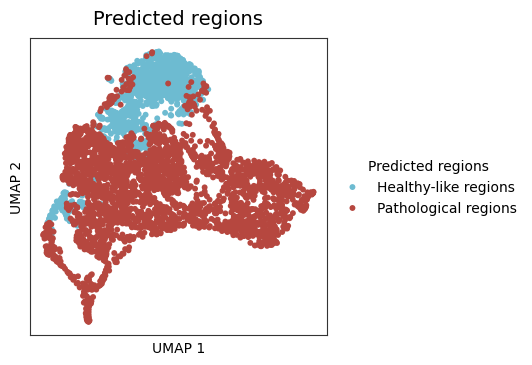

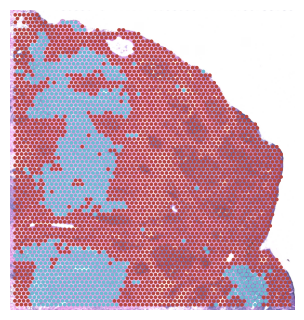

In [10]:
spapath_utils.plot_detection_umap(
    adata=adata_full,
    embed="cell_embed",
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    label_palette=REGION_PALETTE,
    seed=SEED,
    point_size=18,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_detection_umap.png",
)

he_prediction_figure = spapath_utils.plot_prediction_on_he(
    adata=adata_full,
    image_path=HE_IMAGE_PATH,
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    spatial_key="spatial",
    label_palette=REGION_PALETTE,
    coordinate_scale=1.0,
    point_scale=0.85,
    figsize=(3, 3),
    save=FIGURE_DIR / f"{DISEASE_SECTION}_prediction_on_he.png",
)

## 8. Build the all-gene disease dataset

In [11]:
disease_data = spapath_utils.build_disease_data(
    adata_full=adata_full,
    disease_adata_all_genes=disease_adata_all_genes,
    disease_section=DISEASE_SECTION,
)